# Dataset de Temblor Parkinsoniano · Etapa 2: Entrenamiento del CVAE

**Objetivo**: entrenar un Conditional Variational Autoencoder condicionado a 4 etiquetas (DBS × MED) para generar ventanas de velocidad del dedo de 1.2 s cuya distribución se aproxime a la real.

**Dependencias**: `tremor_X_train.npy` y demás ficheros producidos en la Etapa 1.

**Arquitectura** (1D Conv CVAE):
- Encoder: 3 × Conv1D (kernel=7, stride=2) → FC → (μ, logσ²) ∈ ℝ¹⁶
- Reparametrización: z = μ + σ · ε
- Decoder: concat(z, c) → 3 × ConvTranspose1D → salida 1 × 240

**Pérdida** (β-VAE + PSD loss + free-bits):
$$
\mathcal{L} = \frac{1}{2}\|x - \hat x\|^2 + \lambda \cdot \mathrm{MAE}(\mathrm{PSD}(x), \mathrm{PSD}(\hat x)) + \beta(t) \cdot \max(\mathrm{KL} - \mathrm{floor}, 0)
$$

**Medidas clave contra el KL collapse**:
1. β-annealing: 0 → 1.0 over 30 epochs
2. Free-bits: la KL de cada dimensión latente sólo cuenta cuando supera 0.5 nats
3. PSD loss: fomenta la alineación espectral, compensando la debilidad de la MSE en el dominio de la frecuencia

---

## 0. Dependencias

In [2]:
import numpy as np
import json, os, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy import signal as sp_signal

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('✅ device:', device)
torch.manual_seed(42); np.random.seed(42)

✅ device: cpu


In [3]:
#print('numpy:', numpy.__version__)         # debería ser 1.26.x
#print('torch:', torch.__version__)         # 2.2.2

# Probar from_numpy
import numpy as np
x = np.zeros(5, dtype=np.float32)
t = torch.from_numpy(x)
print(x)
print('✅ from_numpy works:', t)

[0. 0. 0. 0. 0.]
✅ from_numpy works: tensor([0., 0., 0., 0., 0.])


## 1. Cargar los productos de la Etapa 1

In [4]:
X_train = np.load('tremor_X_train.npy')
y_train = np.load('tremor_y_train.npy')
X_val   = np.load('tremor_X_val.npy')
y_val   = np.load('tremor_y_val.npy')
X_test  = np.load('tremor_X_test.npy')
y_test  = np.load('tremor_y_test.npy')
with open('label_dict.json') as f:
    LABELS = json.load(f)

WINDOW_LEN = LABELS['window_len']
FS         = LABELS['sampling_rate']
N_COND     = len(LABELS['condition'])    # 4
print(f'Train {X_train.shape}  Val {X_val.shape}  Test {X_test.shape}')
print(f'Window {WINDOW_LEN} samples @ {FS} Hz, conditions = {N_COND}')

Train (7485, 240)  Val (1761, 240)  Test (1899, 240)
Window 240 samples @ 200 Hz, conditions = 4


## 2. Dataset / DataLoader

In [5]:
class TremorDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float().unsqueeze(1)   # (N, 1, L)
        self.c = torch.from_numpy(y[:, 0]).long()           # condition idx
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.c[i]

train_ds = TremorDS(X_train, y_train)
val_ds   = TremorDS(X_val,   y_val)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
print('batches train/val:', len(train_loader), len(val_loader))

batches train/val: 116 28


## 3. Modelo CVAE

In [6]:
LATENT_DIM = 16

def conv_block(in_c, out_c, k=7, s=2):
    pad = k // 2
    return nn.Sequential(
        nn.Conv1d(in_c, out_c, k, stride=s, padding=pad),
        nn.GroupNorm(min(8, out_c), out_c),
        nn.SiLU(),
    )

def deconv_block(in_c, out_c, k=7, s=2, last=False):
    pad = k // 2
    out_pad = 1 if s == 2 else 0
    layers = [nn.ConvTranspose1d(in_c, out_c, k, stride=s, padding=pad, output_padding=out_pad)]
    if not last:
        layers += [nn.GroupNorm(min(8, out_c), out_c), nn.SiLU()]
    return nn.Sequential(*layers)


class CVAE(nn.Module):
    def __init__(self, window_len=240, n_cond=4, latent=16):
        super().__init__()
        self.window_len = window_len; self.n_cond = n_cond; self.latent = latent

        # encoder: 240 → 120 → 60 → 30
        self.enc = nn.Sequential(
            conv_block(1, 32),     # 240 → 120
            conv_block(32, 64),    # 120 → 60
            conv_block(64, 128),   # 60  → 30
        )
        self.enc_flat_dim = 128 * 30
        self.fc_mu     = nn.Linear(self.enc_flat_dim, latent)
        self.fc_logvar = nn.Linear(self.enc_flat_dim, latent)

        # decoder: latent + n_cond → 30 → 60 → 120 → 240
        self.fc_dec = nn.Linear(latent + n_cond, self.enc_flat_dim)
        self.dec = nn.Sequential(
            deconv_block(128, 64),                 # 30  → 60
            deconv_block(64, 32),                  # 60  → 120
            deconv_block(32, 1, last=True),        # 120 → 240
        )

    def encode(self, x):
        h = self.enc(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def decode(self, z, c_onehot):
        h = self.fc_dec(torch.cat([z, c_onehot], dim=1)).view(-1, 128, 30)
        return self.dec(h)

    def forward(self, x, c):
        c_oh = F.one_hot(c, num_classes=self.n_cond).float()
        mu, logvar = self.encode(x)
        z = self.reparameterise(mu, logvar)
        x_hat = self.decode(z, c_oh)
        return x_hat, mu, logvar


model = CVAE(window_len=WINDOW_LEN, n_cond=N_COND, latent=LATENT_DIM).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parámetros del modelo: {n_params/1e3:.1f}k')

Parámetros del modelo: 348.3k


## 4. Función de pérdida

- **Pérdida de reconstrucción**: MSE(x, x̂)
- **Pérdida PSD**: PSD vía torch.fft, luego MAE
- **KL** with **free-bits floor**: max(KL_per_dim - 0.5, 0).sum()
- **β-annealing**: 0 → 1 over 30 epochs

In [7]:
FREE_BITS = 0.5  # nats per latent dim

def psd_torch(x, n_fft=240):
    """x: (B, 1, L) → PSD: (B, n_fft//2 + 1)"""
    spec = torch.fft.rfft(x.squeeze(1), n=n_fft)
    psd  = (spec.real**2 + spec.imag**2) / n_fft
    return psd

def cvae_loss(x, x_hat, mu, logvar, beta):
    # Reconstrucción (sum-then-mean sobre el batch)
    recon = F.mse_loss(x_hat, x, reduction='none').flatten(1).sum(dim=1).mean()
    # PSD
    psd_real, psd_fake = psd_torch(x), psd_torch(x_hat)
    psd_loss = (psd_real - psd_fake).abs().sum(dim=1).mean()
    # KL with free-bits per-dimension
    kl_per_dim = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp())  # (B, latent)
    kl_dim_mean = kl_per_dim.mean(dim=0)                         # (latent,)
    kl_floor    = torch.clamp(kl_dim_mean, min=FREE_BITS)        # evitar collapse
    kl_term     = kl_floor.sum()

    total = recon + 0.1 * psd_loss + beta * kl_term
    return total, {'recon': recon.item(), 'psd': psd_loss.item(), 'kl': kl_term.item()}

## 5. Bucle de entrenamiento

In [8]:
import torch
import torch.nn as nn

N_EPOCHS = 200
WARMUP   = 30      # intervalo del β annealing
LR       = 1e-3
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)

history = {'train': [], 'val': []}
best_val = float('inf'); best_state = None
patience = 25; bad = 0

for epoch in range(N_EPOCHS):
    beta = min(1.0, epoch / WARMUP)
    # ---- train
    model.train()
    s = {'recon': 0, 'psd': 0, 'kl': 0, 'total': 0, 'n': 0}
    for x, c in train_loader:
        x, c = x.to(device), c.to(device)
        x_hat, mu, logvar = model(x, c)
        loss, parts = cvae_loss(x, x_hat, mu, logvar, beta)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        s['recon'] += parts['recon']; s['psd'] += parts['psd']; s['kl'] += parts['kl']
        s['total'] += loss.item(); s['n'] += 1
    train_avg = {k: v / s['n'] for k, v in s.items() if k != 'n'}
    history['train'].append(train_avg)

    # ---- val
    model.eval()
    sv = {'recon': 0, 'psd': 0, 'kl': 0, 'total': 0, 'n': 0}
    with torch.no_grad():
        for x, c in val_loader:
            x, c = x.to(device), c.to(device)
            x_hat, mu, logvar = model(x, c)
            loss, parts = cvae_loss(x, x_hat, mu, logvar, beta=1.0)
            sv['recon'] += parts['recon']; sv['psd'] += parts['psd']; sv['kl'] += parts['kl']
            sv['total'] += loss.item(); sv['n'] += 1
    val_avg = {k: v / sv['n'] for k, v in sv.items() if k != 'n'}
    history['val'].append(val_avg)
    sched.step()

    if epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        print(f'Ep {epoch:3d} β={beta:.2f}  '
              f'train recon={train_avg["recon"]:.3f} psd={train_avg["psd"]:.2f} kl={train_avg["kl"]:.2f} '
              f'| val total={val_avg["total"]:.3f}')

    # early stopping on val total
    if val_avg['total'] < best_val - 1e-3:
        best_val = val_avg['total']; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience and epoch >= WARMUP + 10:
            print(f'\n⚠️ early stop at epoch {epoch} (best val {best_val:.3f})')
            break

if best_state is not None:
    model.load_state_dict(best_state)
torch.save({'state': model.state_dict(), 'config': {
    'window_len': WINDOW_LEN, 'n_cond': N_COND, 'latent': LATENT_DIM
}}, 'cvae_best.pt')
print('✅ Modelo guardado → cvae_best.pt')

Ep   0 β=0.00  train recon=144.979 psd=85.97 kl=508.70 | val total=892.209
Ep  10 β=0.33  train recon=62.958 psd=53.89 kl=32.44 | val total=121.156
Ep  20 β=0.67  train recon=52.682 psd=48.39 kl=25.55 | val total=111.755
Ep  30 β=1.00  train recon=49.434 psd=46.29 kl=21.68 | val total=111.155
Ep  40 β=1.00  train recon=46.389 psd=44.40 kl=21.51 | val total=110.964

⚠️ early stop at epoch 48 (best val 109.804)
✅ Modelo guardado → cvae_best.pt


## 6. Curvas de entrenamiento

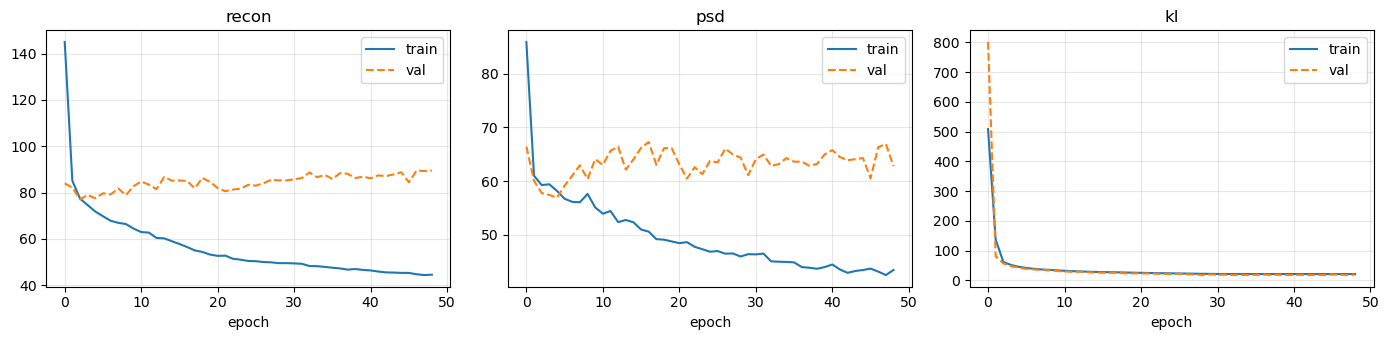

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.5))
keys = ['recon', 'psd', 'kl']
for k, a in zip(keys, ax):
    a.plot([h[k] for h in history['train']], label='train')
    a.plot([h[k] for h in history['val']],   label='val', linestyle='--')
    a.set_title(k); a.set_xlabel('epoch'); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('train_curves.png', dpi=130); plt.show()

## 7. Reconstrucción vs Real — inspección visual

In [10]:
import matplotlib
import matplotlib.pyplot as plt

# Fuentes del sistema en Mac (mantenidas por compatibilidad con etiquetas previas)
matplotlib.rcParams['font.sans-serif'] = [
    'PingFang SC',         # PingFang SC (macOS)
    'Hiragino Sans GB',    # Hiragino Sans GB (macOS)
    'Arial Unicode MS',    # universal en Mac
    'sans-serif'
]
matplotlib.rcParams['axes.unicode_minus'] = False    # evitar que el signo menos se muestre como un cuadrado


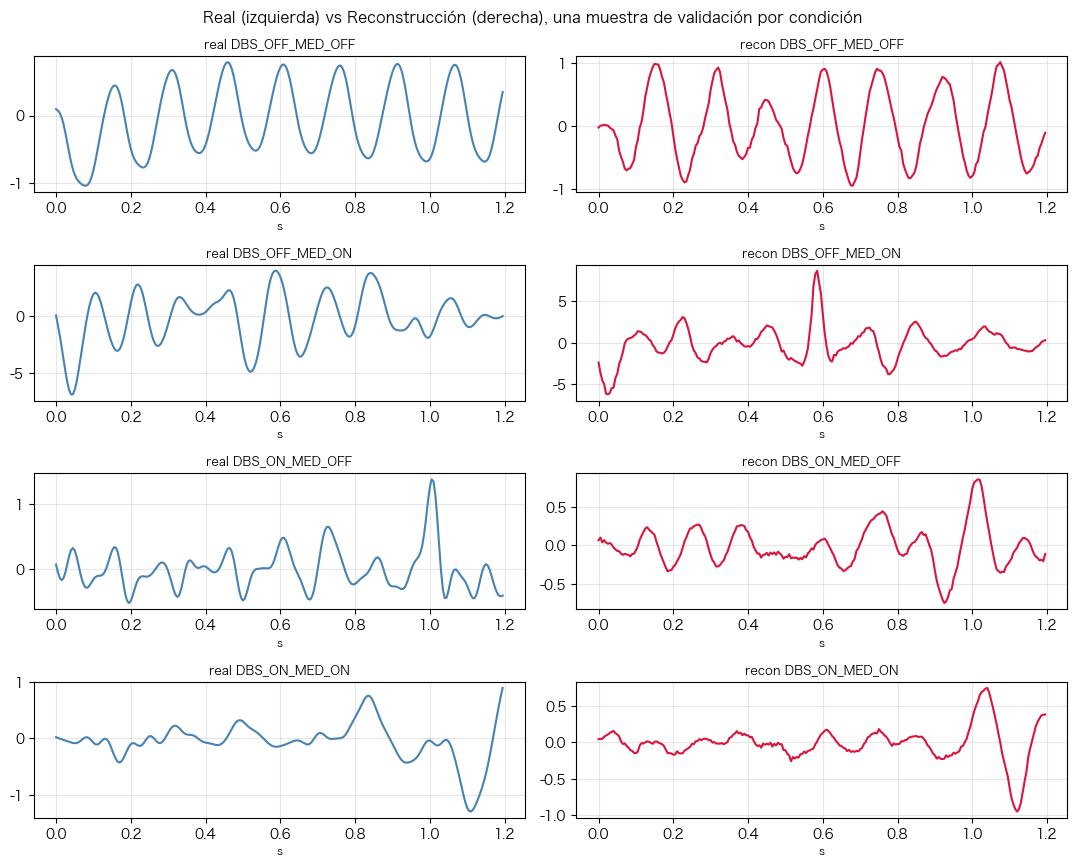

In [11]:
model.eval()
fig, axes = plt.subplots(N_COND, 2, figsize=(11, 2.2 * N_COND))
fig.suptitle('Real (izquierda) vs Reconstrucción (derecha), una muestra de validación por condición', fontsize=11)
COND_INV = {v: k for k, v in LABELS['condition'].items()}

with torch.no_grad():
    for ci in range(N_COND):
        idxs = np.where(y_val[:, 0] == ci)[0]
        if len(idxs) == 0:
            for j in (0, 1):
                axes[ci, j].text(0.5, 0.5, 'no data', ha='center', va='center', transform=axes[ci, j].transAxes)
            continue
        idx = idxs[0]
        x = torch.from_numpy(X_val[idx:idx+1]).float().unsqueeze(1).to(device)
        c = torch.tensor([ci], dtype=torch.long, device=device)
        x_hat, _, _ = model(x, c)
        x_np = x.squeeze().cpu().numpy(); xh_np = x_hat.squeeze().cpu().numpy()
        t = np.arange(WINDOW_LEN) / FS
        axes[ci, 0].plot(t, x_np,  color='steelblue'); axes[ci, 0].set_title(f'real {COND_INV[ci]}', fontsize=9)
        axes[ci, 1].plot(t, xh_np, color='crimson');   axes[ci, 1].set_title(f'recon {COND_INV[ci]}', fontsize=9)
        for j in (0, 1):
            axes[ci, j].grid(alpha=0.3); axes[ci, j].set_xlabel('s', fontsize=8)
plt.tight_layout(); plt.savefig('recon_check.png', dpi=130); plt.show()

## 8. Muestreo condicional — generación de datos sintéticos
Para cada condición, se muestrea z ~ N(0, I) y se pasa por el decoder para generar N ventanas sintéticas.

In [12]:
def sample_cvae(model, condition_idx, n_samples, latent=LATENT_DIM, n_cond=N_COND, device=device):
    """Devuelve ventanas sintéticas con forma (n_samples, window_len)."""
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, latent, device=device)
        c = torch.zeros(n_samples, n_cond, device=device)
        c[:, condition_idx] = 1.0
        x_hat = model.decode(z, c)
    return x_hat.squeeze(1).cpu().numpy()

# Generar 1000 ventanas sintéticas por condición
N_PER_COND = 1000
synth_X = []; synth_y = []
for c, idx in LABELS['condition'].items():
    s = sample_cvae(model, idx, N_PER_COND)
    synth_X.append(s)
    synth_y.append(np.full(N_PER_COND, idx))
synth_X = np.concatenate(synth_X).astype(np.float32)
synth_y = np.concatenate(synth_y).astype(np.int64)

np.save('synth_X.npy', synth_X)
np.save('synth_y.npy', synth_y)
print(f'✅ Datos sintéticos X.shape={synth_X.shape}, y.shape={synth_y.shape}')

✅ Datos sintéticos X.shape=(4000, 240), y.shape=(4000,)


## 9. Resumen PSD: real vs sintético

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

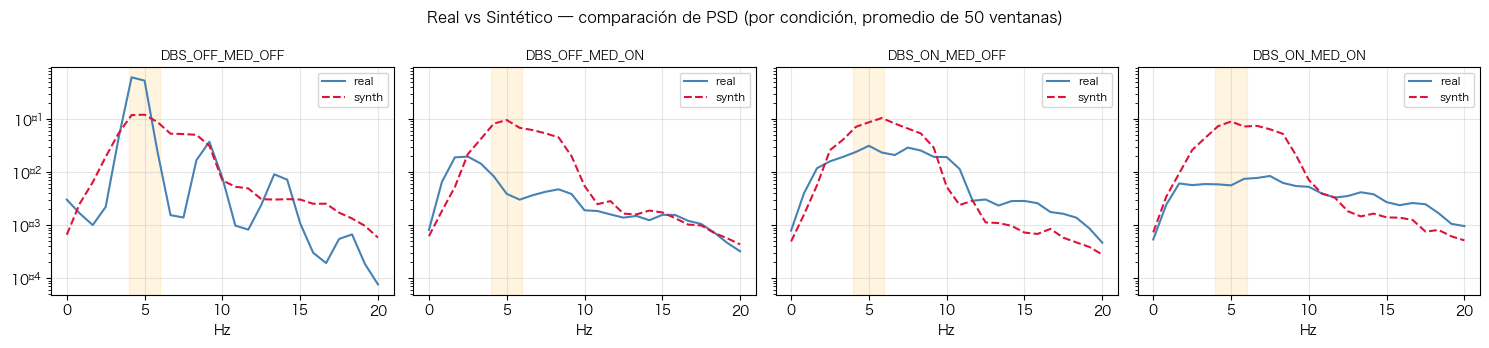

In [13]:
fig, axes = plt.subplots(1, N_COND, figsize=(15, 3.5), sharey=True)
fig.suptitle('Real vs Sintético — comparación de PSD (por condición, promedio de 50 ventanas)', fontsize=11)

for ci, ax in enumerate(axes):
    real_idxs = np.where(y_train[:, 0] == ci)[0][:50]
    fake_idxs = np.where(synth_y == ci)[0][:50]
    if len(real_idxs) == 0 or len(fake_idxs) == 0:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes); continue

    psd_real = np.stack([sp_signal.welch(X_train[i], fs=FS, nperseg=WINDOW_LEN)[1] for i in real_idxs]).mean(0)
    psd_fake = np.stack([sp_signal.welch(synth_X[i], fs=FS, nperseg=WINDOW_LEN)[1] for i in fake_idxs]).mean(0)
    f_axis = sp_signal.welch(X_train[real_idxs[0]], fs=FS, nperseg=WINDOW_LEN)[0]
    mask = f_axis <= 20
    ax.semilogy(f_axis[mask], psd_real[mask], color='steelblue', lw=1.5, label='real')
    ax.semilogy(f_axis[mask], psd_fake[mask], color='crimson',   lw=1.5, label='synth', linestyle='--')
    ax.axvspan(4, 6, color='orange', alpha=0.12)
    ax.set_title(COND_INV[ci], fontsize=9); ax.set_xlabel('Hz'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('psd_real_vs_synth.png', dpi=130); plt.show()

## 10. Resumen de la Etapa 2

| Elemento | Resultado |
|------|------|
| Modelo | 1D Conv CVAE (latent=16, ~150k parámetros) |
| Pérdida | MSE + 0.1·PSD-MAE + β · max(KL_dim - 0.5, 0) |
| β-annealing | 0 → 1.0 durante 30 epochs |
| Free-bits | 0.5 nats / dim |
| Optimizador | AdamW, lr=1e-3, cosine schedule, early stopping |
| Salida | `cvae_best.pt`, `synth_X.npy` (4×1000 ventanas), `synth_y.npy` |

**Siguiente paso → Etapa 3**: usar `synth_X` para pruebas de fidelidad + demo de power en ensayos simulados.